In [1]:
from braket.circuits import Circuit
import itertools as it
import random


def cnot_sequence(circuit_length, input_bits='00'):
    c = Circuit()

    # encode the input
    if input_bits[0] == '1': c.x(0)
    if input_bits[1] == '1': c.x(1)

    # create the CNOT sequence
    for idx in range(circuit_length):
        if idx % 2 == 0: c.cnot(0, 1)
        if idx % 2 == 1: c.cnot(1, 0)

    return c


possible_input_bits      = ('00', '01', '10', '11')
possible_circuit_lengths = (1, 2, 3, 4, 5, 6)
possible_keys = list(it.product(possible_input_bits, possible_circuit_lengths))

circuit_pool             = {}
for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        circuit = cnot_sequence(circuit_length, input_bits=input_bits)
        circuit_pool[(input_bits, circuit_length)] = circuit

def generate_circuit_batch(size):
    random_keys = random.choices(possible_keys, k=size)
    return [(key, circuit_pool[key]) for key in random_keys]

print("EXAMPLE CIRCUIT BATCH")
print("_" * 24)
for key, circuit in generate_circuit_batch(5):
    print()
    print("input_bits={}, length={}".format(*key))
    print("-" * 24)
    print(circuit)
    print("_" * 24)

EXAMPLE CIRCUIT BATCH
________________________

input_bits=11, length=2
------------------------
T  : │  0  │  1  │  2  │
      ┌───┐       ┌───┐ 
q0 : ─┤ X ├───●───┤ X ├─
      └───┘   │   └─┬─┘ 
      ┌───┐ ┌─┴─┐   │   
q1 : ─┤ X ├─┤ X ├───●───
      └───┘ └───┘       
T  : │  0  │  1  │  2  │
________________________

input_bits=00, length=5
------------------------
T  : │  0  │  1  │  2  │  3  │  4  │
            ┌───┐       ┌───┐       
q0 : ───●───┤ X ├───●───┤ X ├───●───
        │   └─┬─┘   │   └─┬─┘   │   
      ┌─┴─┐   │   ┌─┴─┐   │   ┌─┴─┐ 
q1 : ─┤ X ├───●───┤ X ├───●───┤ X ├─
      └───┘       └───┘       └───┘ 
T  : │  0  │  1  │  2  │  3  │  4  │
________________________

input_bits=11, length=5
------------------------
T  : │  0  │  1  │  2  │  3  │  4  │  5  │
      ┌───┐       ┌───┐       ┌───┐       
q0 : ─┤ X ├───●───┤ X ├───●───┤ X ├───●───
      └───┘   │   └─┬─┘   │   └─┬─┘   │   
      ┌───┐ ┌─┴─┐   │   ┌─┴─┐   │   ┌─┴─┐ 
q1 : ─┤ X ├─┤ X ├───●───┤ X ├───●───┤ X ├─

In [2]:
# The following is just a convenient little timer for things that take a while in the code below.
# I snipped it from https://medium.com/@DahlitzF/how-to-create-your-own-timing-context-manager-in-python-a0e944b48cf8

from time import time

class Timer:
    def __init__(self, description):
        self.description = description
    def __enter__(self):
        self.start = time()
    def __exit__(self, type, value, traceback):
        self.end = time()
        print(f"complete: {self.end - self.start:.3f}")

In [3]:
from braket.circuits import Circuit, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice


In [4]:
# On with the actual code...

aws_simulator = AwsDevice("arn:aws:braket:::device/quantum-simulator/amazon/sv1")
#ionq = AwsDevice("arn:aws:braket:us-east-1::device/qpu/ionq/Harmony")
#ionq = AwsDevice("arn:aws:braket:us-east-1::device/qpu/ionq/Aria-1") 
rigetti = AwsDevice("arn:aws:braket:us-west-1::device/qpu/rigetti/Ankaa-3")
# s3_folder = ("amazon-braket-quasimodo-840eb696707f", "yuval_mwe_preliminary")
s3_folder = ("amazon-braket-eng-dev", "yuval_mwe_preliminary")


reference_table = {}

for input_bits in possible_input_bits:
    for circuit_length in possible_circuit_lengths:
        
        circuit_to_simulate = circuit_pool[(input_bits, circuit_length)]
        print(f"Starting job: input_bits={input_bits}, circuit_length={circuit_length}...", end=" ")
        
        with Timer("AWS simulator"):
            # First create the task for Amazon's circuit simulator.
            # Note that the number of shots is irrelevant here;
            # I want the simulated measurement probabilities only.
            task = aws_simulator.run(circuit_to_simulate, s3_folder, shots=1)
            
            # Now I can extract the measurement probabilities.
            # This is a dictionary of the form {correct_output: 1}.
            # The useful information is therefore the key, not the value.
            result = task.result().measurement_probabilities
            correct_output = list(result.keys())[0]
            
            # I now store the correct output in the reference table.
            reference_table[(input_bits, circuit_length)] = correct_output
     

Starting job: input_bits=00, circuit_length=1... complete: 3.687
Starting job: input_bits=00, circuit_length=2... complete: 1.813
Starting job: input_bits=00, circuit_length=3... complete: 2.823
Starting job: input_bits=00, circuit_length=4... complete: 2.727
Starting job: input_bits=00, circuit_length=5... complete: 2.952
Starting job: input_bits=00, circuit_length=6... complete: 1.700
Starting job: input_bits=01, circuit_length=1... complete: 1.842
Starting job: input_bits=01, circuit_length=2... complete: 1.697
Starting job: input_bits=01, circuit_length=3... complete: 1.682
Starting job: input_bits=01, circuit_length=4... complete: 2.739
Starting job: input_bits=01, circuit_length=5... complete: 1.750
Starting job: input_bits=01, circuit_length=6... complete: 2.891
Starting job: input_bits=10, circuit_length=1... complete: 1.717
Starting job: input_bits=10, circuit_length=2... complete: 2.762
Starting job: input_bits=10, circuit_length=3... complete: 2.524
Starting job: input_bits=

In [5]:
for input_bits in possible_input_bits:
    reference = [input_bits] + [reference_table[(input_bits, l)] for l in possible_circuit_lengths]
    print("{} | {} {} {} {} {} {}".format(*reference))


00 | 00 00 00 00 00 00
01 | 01 11 10 10 11 01
10 | 11 01 01 11 10 10
11 | 10 10 11 01 01 11


In [6]:
#test_batch = generate_circuit_batch(1000)
test_batch = generate_circuit_batch(100)
tasks = [rigetti.run(circuit, s3_folder, shots=100) for key, circuit in test_batch]
#tasks = [ionq.run(circuit, s3_folder, shots=1000) for key, circuit in test_batch]
task_id = [t.id for t in tasks]
print(task_id)
     

['arn:aws:braket:us-west-1:835581428919:quantum-task/2342d626-7ae2-431b-b818-89ea4a3c8a2a', 'arn:aws:braket:us-west-1:835581428919:quantum-task/092d7ed6-906c-471e-be8b-1b78ce8b88b7', 'arn:aws:braket:us-west-1:835581428919:quantum-task/d8ccfeb1-5a85-4863-b117-1f99444c0958', 'arn:aws:braket:us-west-1:835581428919:quantum-task/d6665ae6-ed42-468f-be4b-3f808fa3ec8e', 'arn:aws:braket:us-west-1:835581428919:quantum-task/84cd02c7-b7d2-453f-95ad-cabe0c5300cf', 'arn:aws:braket:us-west-1:835581428919:quantum-task/58495d29-0112-43b1-b945-0f27bd2ef71d', 'arn:aws:braket:us-west-1:835581428919:quantum-task/a4ce7a09-fac9-4f7b-89a0-15b6f8c42ef8', 'arn:aws:braket:us-west-1:835581428919:quantum-task/ae08af17-8a00-411a-bbdd-91b893459219', 'arn:aws:braket:us-west-1:835581428919:quantum-task/c9cd2427-0e74-40ef-8a6f-483032173994', 'arn:aws:braket:us-west-1:835581428919:quantum-task/2ae676b2-3e57-4870-b49e-e8a6e0a76724', 'arn:aws:braket:us-west-1:835581428919:quantum-task/e57be822-345b-4907-be5a-6c8ad2d3956b'

In [7]:
state_list = []

with Timer("Fetching the state takes super long..."):
    for k in range(len(tasks)):
        state = tasks[k].state()
        state_list += [state]
        print(f"Task {k:>3}: {state:<10}", end="\r")
    print("State fetch", end=" ")

number_of_tasks_still_queued = sum(1 if state_list[k] == 'QUEUED' else 0
                                   for k in range(len(state_list)))

if number_of_tasks_still_queued == 0:
    print("All tasks complete!")
else:
    print(f"Still waiting on {number_of_tasks_still_queued} tasks.")

State fetch complete: 7.865
All tasks complete!


In [8]:
# for t in tasks:
#     print(t)
#     t.cancel()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

data = []

for idx in range(len(tasks)):
    print(idx)
    #print('DEBUG')
    the_task   = tasks[idx]
    #print('DEBUG')
    task_id    = the_task.id
    #print('DEBUG')
    the_result = the_task.result()
    #print('DEBUG')
    
    start_time   = pd.to_datetime(the_result.task_metadata.createdAt)
    end_time     = pd.to_datetime(the_result.task_metadata.endedAt)
    elapsed_time = end_time - start_time
    
    batch_member   = test_batch[idx]
    circuit_key    = batch_member[0]
    input_bits     = circuit_key[0]
    circuit_length = circuit_key[1]

    
    measurement_probabilities = the_result.measurement_probabilities
    correct_output            = reference_table[circuit_key]
    success_probability       = measurement_probabilities[correct_output]
    
    data.append((task_id,
                 input_bits,
                 circuit_length,
                 start_time,
                 end_time,
                 elapsed_time,
                 success_probability))

data = pd.DataFrame(data, columns=['id_string',
                                   'input_bits',
                                   'circuit_length',
                                   'start_time',
                                   'end_time',
                                   'elapsed_time',
                                   'success_probability'])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [10]:
data

,id_string,input_bits,circuit_length,start_time,end_time,elapsed_time,success_probability
0,arn:aws:braket:us-west-1:835581428919:quantum-...,11,4,2026-02-20 22:09:04.268000+00:00,2026-02-20 22:09:06.880000+00:00,0 days 00:00:02.612000,0.90
1,arn:aws:braket:us-west-1:835581428919:quantum-...,00,3,2026-02-20 22:09:04.528000+00:00,2026-02-20 22:09:07.214000+00:00,0 days 00:00:02.686000,0.94
2,arn:aws:braket:us-west-1:835581428919:quantum-...,00,6,2026-02-20 22:09:04.750000+00:00,2026-02-20 22:09:07.015000+00:00,0 days 00:00:02.265000,0.95
3,arn:aws:braket:us-west-1:835581428919:quantum-...,11,2,2026-02-20 22:09:04.988000+00:00,2026-02-20 22:09:07.100000+00:00,0 days 00:00:02.112000,0.91
4,arn:aws:braket:us-west-1:835581428919:quantum-...,10,3,2026-02-20 22:09:05.249000+00:00,2026-02-20 22:09:07.350000+00:00,0 days 00:00:02.101000,0.94
...,...,...,...,...,...,...,...
95,arn:aws:braket:us-west-1:835581428919:quantum-...,01,1,2026-02-20 22:09:31.314000+00:00,2026-02-20 22:09:31.768000+00:00,0 days 00:00:00.454000,0.91
96,arn:aws:braket:us-west-1:835581428919:quantum-...,10,6,2026-02-20 22:09:31.532000+00:00,2026-02-20 22:09:32.068000+00:00,0 days 00:00:00.536000,0.95
97,arn:aws:braket:us-west-1:835581428919:quantum-...,10,3,2026-02-20 22:09:31.868000+00:00,2026-02-20 22:09:32.414000+00:00,0 days 00:00:00.546000,0.95
98,arn:aws:braket:us-west-1:835581428919:quantum-...,11,2,2026-02-20 22:09:32.110000+00:00,2026-02-20 22:09:32.599000+00:00,0 days 00:00:00.489000,0.90


In [11]:
data.to_csv('data_02_27_26.csv', index=False)

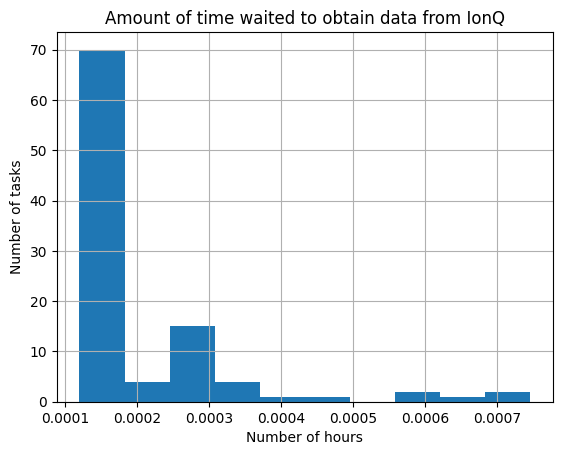

In [12]:
data['elapsed_time_hours'] = data['elapsed_time'].dt.total_seconds() / 3600
data['elapsed_time_hours'].hist()
plt.xlabel("Number of hours")
plt.ylabel("Number of tasks")
plt.title("Amount of time waited to obtain data from IonQ")
plt.show()
     


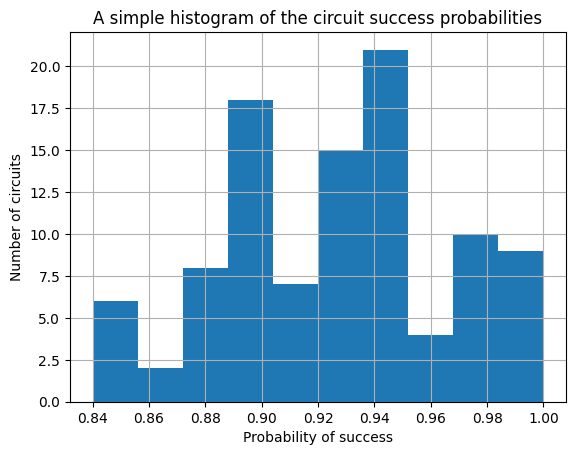

In [13]:
data['success_probability'].hist()
plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("A simple histogram of the circuit success probabilities")
plt.show()
     


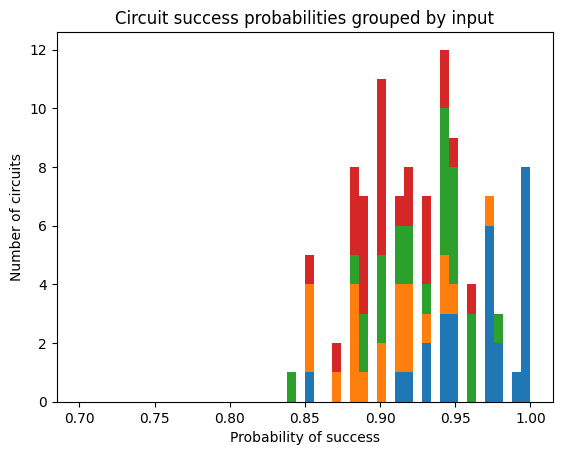

In [14]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("input_bits")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by input")
plt.show()

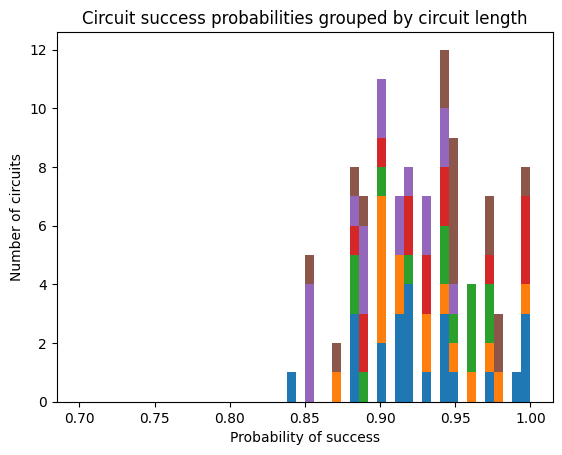

In [15]:
plt.hist([df["success_probability"] for input_bits, df in data.groupby("circuit_length")],
          bins=50, range=(0.7, 1.0), stacked=True)

plt.xlabel("Probability of success")
plt.ylabel("Number of circuits")
plt.title("Circuit success probabilities grouped by circuit length")
plt.show()

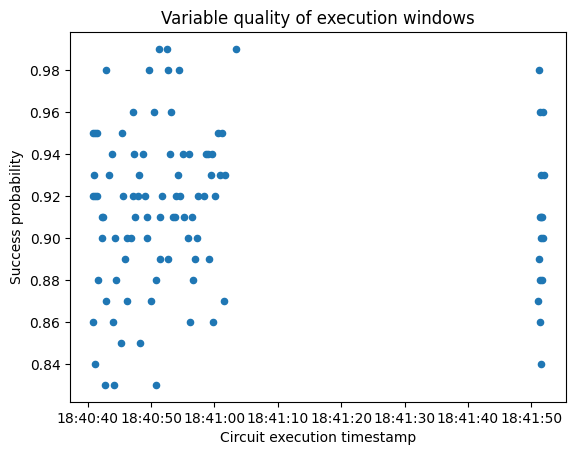

In [21]:
data.plot.scatter(x="end_time", y="success_probability")
plt.xlabel("Circuit execution timestamp")
plt.ylabel("Success probability")
plt.title("Variable quality of execution windows")
plt.show()
     